# Serving, Simulation Eval, and Closing the Loop

## TLDR

You take the PI0.5 checkpoint fine-tuned in notebook 02, deploy it as an HTTP
service with **Ray Serve** on one GPU, then fan out **Isaac Lab** Franka rollouts
as **`@ray.remote(num_gpus=1)`** tasks. Each rollout gets its own GPU, process,
and simulator, and queries the policy over HTTP. Then you **close the loop** by filtering
the sim trajectories by reward, `union()` the good ones into the LIBERO stream,
and retrain. The reward comparison between rounds is the payoff.

## Introduction

A robot foundation model is only as good as its behavior in the world. Training produces a checkpoint. What stands between that checkpoint and a robot you would actually let move is evaluation. Before you ship a policy, or even choose between two of them, you have to watch it act many times, across many starting conditions.

The obvious place to do that is on a physical robot, and that is exactly where it becomes impractical. Real-robot evaluation is slow, expensive, and dangerous. You have a handful of arms or humanoids, every trial needs human supervision and a manual reset, hardware wears out and breaks, and a single bad action chunk can damage the robot or injure someone standing next to it. You cannot run the thousands of trials needed for statistical confidence on physical hardware. Simulation removes every one of those constraints. It is safe, repeatable, parallelizable, and cheap per trial. So serious evaluation happens in simulation first.

However, while simulation removes the bottlenecks of physical evaluation, it replaces them with a distributed-systems problem. Evaluating robot foundation models means running GPU-heavy simulation and GPU-heavy policy inference together across hundreds or thousands of rollouts. At scale, that can quickly become a multi-million-dollar infrastructure problem.


1. **It is a closed loop, not a batch pass.** Policy inference and simulation alternate, step by step, with the output of one feeding the input of the other. You cannot decouple them into independent offline stages.

2. **Two GPU-bound workloads cannot share a process or a GPU.** A multi-billion parameter vision-language-action (VLA) model wants a GPU, and a simulator, such as Isaac Sim's physics and rendering, want a GPU. Co-locate them and they contend for memory and compute, stalling each other. Put them in the same process and their runtimes conflict outright.

3. **Hundreds of rollouts should share one policy, not reload it.** Each rollout needs its own simulator, but all of them can be served by a small fleet of policy replicas. Fuse the two and scaling rollouts means standing up N copies of a large model, which is wasteful and often infeasible on GPU memory.

## Key concepts used in this notebook

**Ray Serve** runs a Python class as a scalable HTTP service. `@serve.deployment`
declares the service (here pinned to 1 GPU); `@serve.ingress(FastAPI())` exposes
routes; `serve.run(...)` deploys it. This is the same primitive used to serve
LLMs in production.

**Pickle-over-HTTP.** Sim workers POST a pickled observation dict and get a
pickled action chunk back. Pickle (not JSON) keeps numpy arrays intact.

**`@ray.remote(num_gpus=1)`** turns a function into a task that Ray schedules on
a free GPU. We launch `SIM_WORKERS` of them and Ray places each on its own GPU and
isolates failures.

**Subprocess, not actor.** Isaac Sim's Kit engine uses asyncio internally. Inside
a Ray actor's event loop scene-loading crashes. So each sim task shells out to
`tools/sim_worker.py`, giving Isaac a clean interpreter + event loop.

**`ray.data.union()`** interleaves two datasets during iteration, This the entire
data-mixing implementation for the closed loop. More complex logic can be implemented as needed.

## What you will learn

- Deploy a GPU policy as an HTTP service with **Ray Serve**
- Fan out parallel **Isaac Lab** rollouts as `@ray.remote(num_gpus=1)` tasks
- Understand the subprocess + HTTP boundary between policy and simulator
- Filter sim trajectories by reward and **`union()`** them into the training
  stream, closing the loop with one line
- Retrain on the mixed data with the **unchanged** `TorchTrainer` from notebook 02 and
  compare rewards across rounds

## Why Ray Serve + Ray tasks?

| Need | Without Ray | With Ray |
|---|---|---|
| Policy as a service on its own GPU | Custom server + device management | `@serve.deployment(num_gpus=1)` + `serve.run` |
| N parallel simulators, each on a GPU | Manual process pool + GPU assignment | `@ray.remote(num_gpus=1)`, Ray schedules |
| Policy/sim runtime isolation | Hope they coexist | Separate processes, HTTP boundary |
| Fault isolation | One crash kills the run | Per-task isolation, free |
| Mix sim data into training | Custom sampler/DataLoader | `libero_ds.union(sim_ds)` |

## Architecture

```
         +------------------------+
         |   Ray Serve replica    |  1 GPU
         |   PI0.5 policy :8000   |<------- POST /predict (pickled obs) --------+
         +------------------------+                                            
                                                                               
   +------------------------ @ray.remote(num_gpus=1) -------------------------+
   |  tools/sim_worker.py (subprocess)        tools/sim_worker.py (subprocess) |
   |  Isaac Lab Franka -- 1 GPU --      Isaac Lab Franka -- 1 GPU --           |
   |   reset->obs->[query policy]->step  reset->obs->[query policy]->step ----+|
   |   saves GIF + trajectory.pkl        saves GIF + trajectory.pkl            |
   +---------------------------------------------------------------------------+
                              | trajectories/*.pkl (reward in filename)
                              v
        filter reward >= theta -> ray.data.from_items -> libero_ds.union(sim_ds)
                              |
                              v  retrain (notebook 02's TorchTrainer, unchanged)
```

The diagram shows two simulators because that is the smallest interesting fan-out.
The actual count is derived from the cluster below: one rollout per GPU node, and
never more than the GPUs left over once the policy replica has one. That is 1
rollout on a 2-GPU cluster and 3 across four single-GPU nodes, and in production
the same block scales to as many nodes as you point it at.

## Cell 1: Configuration

**What you do:** set the serving/sim hyper-parameters and point at the
round-1 checkpoint produced by **notebook 02**.

**What to check:** `R1_CKPT` exists (run notebook 02 first). `SIM_WORKERS` is
derived from the cluster: one rollout per GPU node, and never more than
*GPUs − 1*, since the Serve replica holds one GPU for the whole sim phase. That
is 1 rollout on a 2-GPU cluster, 3 across four single-GPU nodes, and 1 on a
single 4-GPU node. Ray releases GPUs between phases, so whatever the size, the
cluster is never over-subscribed and the retrain afterwards gets all of them.
Set `SIM_WORKERS` in the environment to fan out further on one node.

**Why it matters:** these are the only knobs. The serving, sim, and training
code below is unchanged from a single-GPU prototype to a large fleet.

In [1]:
import logging, os, shutil, sys, time, glob, pickle, socket, subprocess, json
from pathlib import Path
import numpy as np
import torch

logging.basicConfig(level=logging.WARNING, format="%(asctime)s  %(levelname)-8s  %(message)s")
# Notebook code logs at INFO; third-party libraries stay at WARNING. A root
# logger set to INFO also picks up import-time chatter that reads like a fault
# and is not: Ray's preprocessor registry logs six "Preprocessor id collision:
# ... Overwriting with ray.anyscale...turbo_encoder" lines through the ROOT
# logger during ray.init, which is only Anyscale's accelerated encoders
# replacing the open-source ones.
log = logging.getLogger("serve_sim")
log.setLevel(logging.INFO)
logging.getLogger("lerobot_datasource").setLevel(logging.INFO)

# All data comes from the PUBLIC S3 mirror; no Hugging Face at runtime (see notebook 02).
# LEROBOT_S3_ANON -> unsigned reads of the public bucket; HF_HUB_OFFLINE -> the PaliGemma
# tokenizer loads from the image's baked cache. Set before importing the datasource; also
# re-declared in ray.init so workers and the Serve replica inherit them.
os.environ["LEROBOT_S3_ANON"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

MIRROR_ROOT     = "s3://anyscale-public-materials-use2/ray_summit_robotics_2026"
HF_PI05_REPO    = "lerobot/pi05_libero_finetuned"   # breadcrumb stored in checkpoints
HF_DATASET_URI  = f"{MIRROR_ROOT}/libero"
MODEL_S3_URI    = f"{MIRROR_ROOT}/pi05_libero_finetuned"   # staged per node below

LOCAL_MODEL_DIR      = Path("/mnt/local_storage/lerobot/pi05_libero_finetuned")
CLUSTER_STORAGE_ROOT = Path("/mnt/cluster_storage/vla_closed_loop_demo")
OUTPUT_DIR           = CLUSTER_STORAGE_ROOT / "rollouts"
CAMERA_RENAME        = {}

REWARD_THRESHOLD = 0.5     # keep sim episodes with reward >= this
# Sim fan-out, derived from the live cluster by cluster.sim_workers():
#   the Serve policy replica holds 1 GPU for the whole sim phase and each rollout
#   takes 1 more, so the ceiling is (total GPUs - 1), and we also keep it to one
#   rollout per GPU node so each node boots one Isaac Sim runtime at a time. That
#   is 1 rollout on a 2-GPU cluster, 3 across four single-GPU nodes, and 1 on a
#   single 4-GPU node. serve.shutdown() below releases the replica before the next
#   training round, so the retrain gets every GPU back. Set the SIM_WORKERS env
#   var to fan out further on one node; franka_env serializes the boots.
#   Read after ray.init in the Ray-connect cell below, since there is nothing to
#   read from yet at this point in the notebook.
SIM_WORKERS      = None    # -> cluster.sim_workers() once Ray is up
SIM_EPISODES     = 1       # episodes per worker
MAX_SIM_STEPS    = 100     # steps per episode
ACTION_HORIZON   = 10      # re-query the policy every N steps
INSTRUCTION      = "pick up the cube and lift it"
# PI0.5 is an action-CHUNKING policy: its config sets chunk_size == n_action_steps
# == 50, and the flow-matching loss compares v_t of shape [B, 50, action_dim]
# against u_t built from the target. Feeding one action per frame leaves u_t as
# [B, action_dim] and v_t as [B, 1, action_dim], and F.mse_loss BROADCASTS rather
# than raising -- so the model trains against a spurious axis and never learns
# chunks. The datasource assembles real chunks when told the size; it must match
# the policy config.
ACTION_CHUNK_SIZE = 50

# Round-2 retrain budget in BATCHES (smoke run; None trains a full epoch).
# 100 batches at grad_accum=4 is 25 optimizer updates, enough for the
# retrained policy to measurably differ from round 1. The earlier 50 at
# grad_accum=16 gave 3 updates, and with the LR schedule sized for a full
# 273k-row epoch those landed at ~1e-7 -- round 2 came back within fp16 noise
# of round 1 (~1e-6 relative), which is why both rounds scored 0.740.
MAX_TRAIN_STEPS  = 100
# Ray Train RESTORES any run directory whose name matches, and a restored run
# that already finished its epochs runs zero steps while still reporting the
# earlier checkpoint and metrics as if they were new. Clear it so re-running
# this notebook always retrains.
FRESH_TRAIN      = True

# Checkpoint produced by notebook 02 (shared cluster storage).
R1_CKPT = CLUSTER_STORAGE_ROOT / "checkpoint_round1" / "state.pkl"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Round-1 checkpoint:", R1_CKPT, "| exists:", R1_CKPT.exists())


Round-1 checkpoint: /mnt/cluster_storage/vla_closed_loop_demo/checkpoint_round1/state.pkl | exists: False


## Cell 2: Connect to Ray

**What you do:** connect and thread the env every worker needs: training vars
(NCCL, dynamo) **and** Isaac Sim's headless Vulkan/EULA vars (sim workers
render GPU frames headless).

**Why it matters:** `working_dir="."` ships `tools/policy_server.py`, `tools/franka_env.py`,
and `tools/sim_worker.py` to every node, so the Serve replica and the `@ray.remote`
sim tasks can import them.

In [2]:
import ray

# Named rather than inlined so the environment every worker, replica and sim
# subprocess inherits is readable in one place. Ray Serve replicas pick this up
# indirectly, through the job that starts the Serve controller -- see
# ensure_serve_owned_by_this_run() in the deploy cell for why that matters.
RUNTIME_ENV = {
        "working_dir": ".",
        # Ship only what the workers import. Without excludes, the uploaded
        # package carries this repo's 29 MB .git directory and 5 MB of GIFs,
        # and Ray warns "File .../.git/objects/pack/pack-*.pack is very large"
        # on every ray.init.
        "excludes": [".git", "__pycache__", "assets", "*.ipynb"],
        "env_vars": {
            "LEROBOT_S3_ANON":           "1",   # unsigned reads of the public S3 mirror
            "HF_HUB_OFFLINE":            "1",    # PaliGemma tokenizer from the baked image cache
            "TRANSFORMERS_OFFLINE":      "1",
            "HF_HUB_ENABLE_HF_TRANSFER": "1",
            "PYTORCH_CUDA_ALLOC_CONF":   "expandable_segments:True",
            "TORCHDYNAMO_DISABLE":       "1",
            "NCCL_P2P_DISABLE":          "1",
            "NCCL_SHM_DISABLE":          "1",
            "NCCL_IB_DISABLE":           "1",
            "VK_ICD_FILENAMES":          "/etc/vulkan/icd.d/nvidia_icd.json",
            "VK_DRIVER_FILES":           "/etc/vulkan/icd.d/nvidia_icd.json",
            "OMNI_KIT_ACCEPT_EULA":      "YES",
            "ACCEPT_EULA":               "Y",
            # PI0.5 takes ~85s to load into a replica, so Serve's default 30s
            # threshold reports the healthy startup as slow every 30s:
            #   "Deployment 'PI05PolicyServer' ... has 1 replica that has taken
            #    more than 30s to be scheduled."
            # Tell it what this model actually costs to load.
            "SERVE_SLOW_STARTUP_WARNING_S": "180",
        },
}

ray.init(
    address="auto",
    runtime_env=RUNTIME_ENV,
    ignore_reinit_error=True,
)
logging.getLogger("ray.data").setLevel(logging.WARNING)
logging.getLogger("openlineage").setLevel(logging.WARNING)
# Progress bars cannot render into a notebook's non-interactive stdout, so
# Ray Data falls back to reprinting every operator's counts as plain text --
# dozens of SplitCoordinator lines per dataset. The training loop already
# logs its own progress every 10 steps.
ray.data.DataContext.get_current().enable_progress_bars = False
# Cap what Ray Data may hold in the object store (notebook 02 does the same).
# The reference worker node has 32 GB of host RAM and the raylet reserves ~10 GB of
# it for plasma; unbounded, the video readers outrun the GPU consumers, the queue spills,
# and the leftover idle spill workers stay resident -- which is what leaves a
# post-training node with too little headroom for the next model load.
ray.data.DataContext.get_current().execution_options.resource_limits = (
    ray.data.ExecutionResources.for_limits(object_store_memory=4 * 1024**3)
)

from tools import cluster
cluster.describe()   # GPU count/model, node layout, and the derived worker counts

# Now that Ray is up, size the sim fan-out: one GPU for the Serve policy replica,
# then one Isaac Lab rollout per remaining GPU node.
SIM_WORKERS = cluster.sim_workers(reserve_for_serve=1)
print(f"sim workers per round: {SIM_WORKERS} (1 GPU each, plus 1 for the policy replica)")

2026-08-24 20:32:21,879	INFO worker.py:1821 -- Connecting to existing Ray cluster at address: 100.103.200.12:6379...
2026-08-24 20:32:21,891	INFO worker.py:1998 -- Connected to Ray cluster. View the dashboard at https://session-tsa5wshpunyjjeptybf1xnuele.i.anyscaleuserdata.com 
2026-08-24 20:32:21,900	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/.gitignore')]
2026-08-24 20:32:21,904	INFO packaging.py:691 -- Creating a file package for local module '.'.
2026-08-24 20:32:21,905	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/.gitignore')]
2026-08-24 20:32:21,909	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_17652851c70f860d.zip' (0.15MiB) to Ray cluster...
2026-08-24 20:32:21,911	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_17652851c70f860d.zip'.
/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Ti

Cluster: 4 GPU(s) (T4) across 1 GPU node(s), 48 CPUs total
  ip-10-0-35-1: 4 x T4, 48 CPU, 192 GiB Ray memory
Derived: train workers = 4, sim workers (nb03) = 1
sim workers per round: 1 (1 GPU each, plus 1 for the policy replica)


## Cell 3: Data stream + preprocessing (from notebooks 01 & 02)

**What you do:** open the LIBERO datasource, extract `STATS`, and rebuild the
`transpose_images` / `build_libero_dataset` pipeline. These are needed for the
round-2 retrain (the LIBERO half of the mixed dataset).

**Why it matters:** the closed loop reuses the exact data pipeline from
notebook 01 and `transpose_images` also handles the sim frames merged in later.

In [3]:
from tools import util
from tools.lerobot_datasource import LeRobotDatasource

# Notebook 03 previously assumed notebook 02 had already staged the model onto
# every node. That holds only until the autoscaler replaces a node: the Serve
# replica or a train worker then finds no local model dir, and lerobot's
# PreTrainedConfig.from_pretrained falls through to hf_hub_download() and raises
#   HFValidationError: Repo id must be in the form 'repo_name' ...
# Staging here (and again per-worker in the training loop) makes 03 standalone.
util.stage_on_all_nodes(
    ray, lambda: util.stage_model_to_local(MODEL_S3_URI, LOCAL_MODEL_DIR),
    MODEL_S3_URI, LOCAL_MODEL_DIR, log_fn=log.info,
)

NUM_TRAIN_WORKERS = cluster.train_workers()   # one per GPU, read from the cluster
print(f"train workers available: {NUM_TRAIN_WORKERS}")

source       = LeRobotDatasource(HF_DATASET_URI, action_chunk_size=ACTION_CHUNK_SIZE)
TOTAL_FRAMES = source.meta.total_frames
STATS        = {k: {"mean": v["mean"], "std": v["std"]}
                for k, v in source.meta.stats.items()
                if k in ("action", "observation.state")}
IMAGE_KEYS   = [CAMERA_RENAME.get(k, k) for k in source.meta.video_keys]


def rename_columns(row, rename):
    return {rename.get(k, k): v for k, v in row.items()}


def transpose_images(batch, camera_keys):
    """HWC -> CHW, staying uint8. Used for LIBERO frames and sim frames alike.

    The float32 cast is deliberately left to the GPU-side collate. A 256x256x3
    frame is 197 KB as uint8 and 786 KB as float32, and the datasource sizes its
    blocks assuming uint8 -- so casting here made every block 4x larger than the
    streaming executor accounted for, and on a 32 GB node the host OOM killer
    reaped the raylet (taking the whole node, and everything on it, down).
    """
    out = dict(batch)
    for key in camera_keys:
        out[key] = np.transpose(np.stack(list(batch[key])), (0, 3, 1, 2))
    return out


def build_libero_dataset(max_steps=MAX_TRAIN_STEPS, batch_size=1,
                         num_workers=None):
    """Stream LIBERO frames, reading only what the step budget consumes.

    The round-2 retrain is a 50-step smoke run: ~100 rows out of 273,465. Left
    unbounded, the video readers outrun the GPU consumers by orders of magnitude
    and the map output queue grows until it spills. MAX_TRAIN_STEPS=None reads
    the full epoch, as before.
    """
    num_workers = NUM_TRAIN_WORKERS if num_workers is None else num_workers
    ds = ray.data.read_datasource(source)
    if max_steps:
        ds = ds.limit(max_steps * batch_size * num_workers + 32 * num_workers)
    return (
        ds
        .map(rename_columns, fn_args=(CAMERA_RENAME,))
        .map_batches(transpose_images, batch_size=32, fn_args=(IMAGE_KEYS,))
    )

print("Data pipeline ready;", f"{TOTAL_FRAMES:,} LIBERO frames available to stream")


2026-08-24 20:32:23,167  INFO      Staging s3://anyscale-public-materials-use2/ray_summit_robotics_2026/pi05_libero_finetuned -> /mnt/local_storage/lerobot/pi05_libero_finetuned ...
2026-08-24 20:32:23,167  INFO        on head: cached: /mnt/local_storage/lerobot/pi05_libero_finetuned
2026-08-24 20:32:50,907  INFO        ip-10-0-35-1: downloaded: /mnt/local_storage/lerobot/pi05_libero_finetuned


(raylet) WARNING: 4 PYTHON worker processes have been started on node: e2540282a979ee7d9d27f7d0fd5d58171e0d7bc2e61c9029693fe41d with address: 100.103.200.12. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
train workers available: 4
Data pipeline ready; 273,465 LIBERO frames available to stream


## Cell 4: The training functions (identical to notebook 02)

**What you do:** reproduce `train_loop_per_worker` and `run_training` exactly as
in notebook 02, so this notebook is self-contained and can run the round-2
retrain.

**What to check:** this is the **same code** you studied in 02. The point of the
closed loop is that *nothing about training changes*, only the dataset does.

**Why it matters:** it makes concrete the architecture claim: `union()` is the
entire data-mixing implementation and the trainer is reused verbatim.

In [4]:
import ray.train
import ray.train.torch


def train_loop_per_worker(config):
    device = torch.device("cuda")

    # Stage onto THIS node before loading. Idempotent, so it is a no-op where the
    # driver already staged; it covers workers placed on nodes the autoscaler
    # added afterwards, which is what produced the HFValidationError.
    util.stage_model_to_local(config["model_uri"], config["model_dir"])

    policy = util.load_pi05_policy(config["model_dir"])
    policy = ray.train.torch.prepare_model(policy)

    optimizer = torch.optim.AdamW(
        [p for p in policy.parameters() if p.requires_grad],
        lr=config.get("lr", 5e-5),
    )
    scaler = torch.amp.GradScaler("cuda")

    checkpoint = ray.train.get_checkpoint()
    start_epoch, step = (util.load_checkpoint(checkpoint, policy, optimizer, scaler)
                         if checkpoint else (0, 0))

    # util.build_preprocessor pins the pipeline's DeviceProcessorStep to cuda.
    # The saved preprocessor JSON says "cpu" and does not inherit
    # policy.config.device, so the default pipeline pulls every batch back to the
    # host and the CUDA model then meets CPU token ids ("two devices, cuda:0 and
    # cpu", index_select). tools/policy_server.py re-uploads the batch to work around
    # this; overriding the step avoids the GPU->CPU->GPU round trip entirely.
    preprocessor, _ = util.build_preprocessor(
        policy.module.config, config["model_dir"], config["stats"], device=device,
    )

    batch_size      = int(config.get("batch_size", 1))
    grad_accum      = int(config.get("grad_accum", 8))
    num_epochs      = int(config.get("num_epochs", 1))
    max_len         = int(config.get("max_len", 512))
    max_train_steps = config.get("max_train_steps")
    num_workers     = ray.train.get_context().get_world_size()
    rank            = ray.train.get_context().get_world_rank()
    scheduler       = util.build_lr_scheduler(optimizer, config, num_workers, last_step=step)
    shard           = ray.train.get_dataset_shard("train")

    # image_keys marks the columns arriving as uint8, widened to float32 here on
    # the GPU rather than back in the Ray Data pipeline.
    collate = util.NumpyToTorchCollate(device, image_keys=config["image_keys"])

    # A restored checkpoint from a completed run makes this loop range(1, 1) --
    # zero iterations, no ray.train.report, and fit() then returns the PREVIOUS
    # run's checkpoint and metrics as if they were fresh. Say so instead.
    if util.resume_would_skip_training(start_epoch, num_epochs):
        log.warning(
            "RESUMED A COMPLETED RUN: checkpoint is at epoch %d and num_epochs=%d, "
            "so NO training steps will run. Any metrics below are from the earlier "
            "run. To retrain, raise num_epochs or change RunConfig(name=...).",
            start_epoch - 1, num_epochs,
        )
        ray.train.report({"epoch": start_epoch - 1, "steps": step, "loss": float("nan"),
                          "lr": float("nan"), "skipped_resumed_complete": True})
        return

    for epoch in range(start_epoch, num_epochs):
        optimizer.zero_grad(set_to_none=True)
        accum = 0
        loss_sum, loss_count = 0.0, 0

        for batch in shard.iter_torch_batches(batch_size=batch_size, collate_fn=collate):
            loss_val = util.train_step(policy, batch, preprocessor, max_len, grad_accum, scaler)
            step += 1; accum += 1
            loss_sum += loss_val; loss_count += 1

            if accum % grad_accum == 0:
                util.optimizer_step(policy, optimizer, scaler, scheduler)
                accum = 0

            if step % 10 == 0 and rank == 0:
                log.info("epoch=%d  step=%d  loss=%.4f  lr=%.2e  gpu_peak=%.1f GB",
                         epoch, step, loss_val, scheduler.get_last_lr()[0],
                         torch.cuda.max_memory_allocated() / 1e9)

            if max_train_steps and step >= max_train_steps:
                break

        if accum > 0:
            util.optimizer_step(policy, optimizer, scaler, scheduler)

        avg_loss = loss_sum / max(loss_count, 1)
        metrics  = {"epoch": epoch, "steps": step,
                    "loss": avg_loss, "lr": scheduler.get_last_lr()[0],
                    "gpu_peak_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2)}

        if rank == 0:
            ckpt = util.make_checkpoint(
                policy, optimizer, scaler, epoch, step, config["stats"],
                base_model_repo=HF_PI05_REPO, camera_rename=CAMERA_RENAME,
            )
            ray.train.report(metrics, checkpoint=ckpt)
        else:
            ray.train.report(metrics)

        if max_train_steps and step >= max_train_steps:
            break


def run_training(ds, round_name):
    """Run TorchTrainer on `ds`, copy checkpoint to a stable path, return path + metrics."""
    CLUSTER_STORAGE_ROOT.mkdir(parents=True, exist_ok=True)

    # Ray Train RESTORES any existing run with this name. If that run already
    # finished its epochs, the train loop body never executes and fit() returns
    # the OLD checkpoint and metrics -- so the "Final metrics" printed below
    # would describe training that did not happen. Warn on the driver, where
    # that output is actually read.
    prior_run = CLUSTER_STORAGE_ROOT / f"vla-finetune-{round_name}"
    if prior_run.exists() and FRESH_TRAIN:
        shutil.rmtree(prior_run)
        log.info("FRESH_TRAIN: removed previous run dir %s", prior_run)
    elif prior_run.exists() and any(prior_run.glob("checkpoint_*")):
        log.warning(
            "run %r already exists at %s -- Ray Train will RESTORE it, not retrain. "
            "If it completed its epochs, the metrics and checkpoint below come from "
            "that earlier run. Delete that directory or use a new round_name to "
            "train from scratch.", prior_run.name, prior_run,
        )



    # Ray Train places one worker per node, and loading PI0.5 spikes host RAM to
    # ~16 GB transiently (steady state is only ~3.3 GB). A node left holding idle
    # spill workers from an earlier stage can have as little as ~12 GB free, and
    # the worker is then killed mid-load:
    #   Worker exit type: SYSTEM_ERROR
    #   Worker unexpectedly exits with a connection error code 2. End of file.
    # That is the host OOM killer, surfaced as a worker health-check failure.
    # require_all=True because EVERY node will host a worker, not just one.
    util.release_phase(ray, log_fn=log.info)
    util.wait_for_host_headroom(ray, need_mib=17_000, require_all=True,
                            num_workers=NUM_TRAIN_WORKERS, log_fn=log.info)

    result = ray.train.torch.TorchTrainer(
        train_loop_per_worker=train_loop_per_worker,
        train_loop_config={
            "stats":           STATS,
            "total_rows":      TOTAL_FRAMES,
            "num_epochs":      1,
            "batch_size":      1,      # measured peak ~8.9 GB at bs=1, fits a 16 GB GPU
            # 4, not 16: at MAX_TRAIN_STEPS=100 that is 25 optimizer updates
            # instead of 6. Peak GPU memory is set by batch_size, not by this.
            "grad_accum":      4,
            "lr":              5e-5,
            "warmup_frac":     0.1,
            "max_len":         512,
            "max_train_steps": MAX_TRAIN_STEPS,
            "image_keys":      IMAGE_KEYS,
            "model_uri":       MODEL_S3_URI,
            "model_dir":       LOCAL_MODEL_DIR,
        },
        scaling_config=ray.train.ScalingConfig(num_workers=NUM_TRAIN_WORKERS, use_gpu=True),
        run_config=ray.train.RunConfig(
            name=f"vla-finetune-{round_name}",
            storage_path=str(CLUSTER_STORAGE_ROOT),
            failure_config=ray.train.FailureConfig(max_failures=1),
            checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1),
        ),
        datasets={"train": ds},
    ).fit()

    checkpoint_path = CLUSTER_STORAGE_ROOT / f"checkpoint_{round_name}" / "state.pkl"
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    with result.checkpoint.as_directory() as d:
        shutil.copy2(os.path.join(d, "state.pkl"), checkpoint_path)

    log.info("[%s] checkpoint -> %s", round_name, checkpoint_path)
    return checkpoint_path, result.metrics


## Cell 5: Deploy + fan-out helper (`run_sim_eval`)

**What you do:** define `run_sim_eval`. It shuts down any prior Serve, deploys
`PI05PolicyServer` on 1 GPU, sanity-pings `/predict`, then fans out `SIM_WORKERS`
`@ray.remote(num_gpus=1)` tasks, each shelling out to `tools/sim_worker.py`, which
boots Isaac Lab, queries the policy over HTTP, and saves a GIF + a trajectory
pickle (reward in the filename). It runs `serve.shutdown()` at the end to free the
GPU for the next training round.

**What to check:** the `@ray.remote(num_gpus=1)` decorator on the inner
function, and the HTTP POST to `http://HEAD:8000/predict`.

**Why it matters:** this is the policy-as-a-service + parallel-sim pattern, and
the GPU hand-back is what keeps the 4-GPU cluster from over-subscribing.

In [5]:
from ray import serve
from tools.policy_server import PI05PolicyServer
import pickle, requests


def _head_ip():
    try:
        return ray.get_runtime_context().gcs_address.split(":")[0]
    except Exception:
        with socket.socket(socket.AF_INET, socket.SOCK_DGRAM) as s:
            s.connect(("8.8.8.8", 80))
            return s.getsockname()[0]


APP_NAME = "pi05-policy"


_SERVE_INSTANCE_IS_OURS = False


def ensure_serve_owned_by_this_run():
    """Guarantee the Serve instance belongs to THIS notebook run.

    Serve's controller is a detached actor: it outlives the job that created
    it, and the replicas it starts inherit THAT job's runtime_env -- meaning
    the code that job uploaded. So a controller left over from an earlier run
    keeps serving the old tools/policy_server.py no matter what you edit here.
    Shutting Serve down once, at the start of the run, makes the next
    serve.run() create the controller under this job, so replicas load this
    run's code. (Pinning runtime_env on the deployment instead does not work:
    Serve requires an already-uploaded URI there, not a local working_dir.)

    Between rounds we only delete the application, which frees the GPU replica
    without disturbing the controller this run just established.
    """
    global _SERVE_INSTANCE_IS_OURS
    if _SERVE_INSTANCE_IS_OURS:
        delete_policy_app()
        return
    serve.shutdown()          # no-op on a fresh cluster
    _SERVE_INSTANCE_IS_OURS = True


def delete_policy_app():
    """Remove the policy application, freeing its GPU replica.

    serve.delete() rather than serve.shutdown(): deleting the application
    releases the GPU-holding replica, which is all the next training round
    needs, and leaves the CPU-only controller and proxies up to serve the
    following round. serve.shutdown() instead tears the controller down via
    graceful_shutdown(), which by design never returns -- the controller kills
    itself while the call is in flight -- so the raylet narrates the clean
    teardown on the driver as
      (raylet) Task ServeController.graceful_shutdown failed. There are
      infinite retries remaining, so the task will be retried. Error: The
      actor is dead because it was killed by `ray.kill`.
    Nothing is wrong when that appears, but it reads like a crash.
    """
    if APP_NAME in serve.status().applications:
        serve.delete(APP_NAME)


def run_sim_eval(checkpoint_path, round_name):
    """Deploy Serve, fan out sim workers, return episode results (with trajectory paths)."""
    traj_dir   = str(CLUSTER_STORAGE_ROOT / "trajectories" / round_name)
    output_dir = str(OUTPUT_DIR / round_name)
    Path(traj_dir).mkdir(parents=True, exist_ok=True)
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # -- Deploy policy server on 1 GPU ----------------------------------------
    # Clear any policy app left behind by an earlier round, and on the first
    # call take ownership of the Serve instance itself.
    ensure_serve_owned_by_this_run()

    # Loading PI0.5 costs a transient ~16 GB of host RAM (measured; the loaded
    # policy then sits at only ~3.3 GB resident). A fresh 32 GB node has ~26 GB
    # available and absorbs that fine, but a node that just ran a Ray Train round
    # still holds plasma plus idle spill workers and has ~18 GB -- right at the
    # edge. Overshooting does not raise: the host OOM killer SIGKILLs the raylet,
    # the node is "marked dead", and everything on it fails in a confusing
    # cascade. So release the previous phase and wait for real headroom first.
    util.release_phase(ray, log_fn=log.info)
    util.wait_for_host_headroom(ray, need_mib=17_000, log_fn=log.info)

    serve.start(http_options={"host": "0.0.0.0", "port": 8000})
    serve.run(
        PI05PolicyServer.bind(
            checkpoint_path=str(checkpoint_path),
            base_model_dir=str(LOCAL_MODEL_DIR),
        ),
        name=APP_NAME,
    )
    print(f"[{round_name}] Policy server deployed (~85s model load)")

    policy_url = f"http://{_head_ip()}:8000"

    # -- Sanity ping -----------------------------------------------------------
    dummy = {
        "observation.images.image":  np.zeros((256, 256, 3), dtype=np.uint8),
        "observation.images.image2": np.zeros((256, 256, 3), dtype=np.uint8),
        "observation.state":         np.zeros((8,),  dtype=np.float32),
        "task":                      INSTRUCTION,
    }
    r = requests.post(f"{policy_url}/predict", data=pickle.dumps(dummy), timeout=180)
    r.raise_for_status()
    print(f"[{round_name}] Sanity ping OK, action shape {pickle.loads(r.content)['action'].shape}")

    # -- Fan out sim workers, each on its own GPU ----------------------------
    @ray.remote(num_gpus=1)
    def run_sim_subprocess(worker_id, policy_url, output_dir, traj_dir, cli_args):
        results_file = f"/tmp/closed_loop_{worker_id}_{round_name}.json"
        cmd = (
            f"timeout 1200 python -u tools/sim_worker.py "
            f"--worker-id {worker_id} "
            f"--policy-url {policy_url} "
            f"--results-file {results_file} "
            f"--save-trajectories '{traj_dir}' "
            f"{cli_args}"
        )
        proc = subprocess.run(
            cmd, shell=True, capture_output=True, text=True, executable="/bin/bash",
        )
        try:
            with open(results_file) as f: results = json.load(f)
        except Exception: results = []
        return {
            "host":        os.uname().nodename,
            "worker_id":   worker_id,
            "exit_code":   proc.returncode,
            "stdout_tail": "\n".join(proc.stdout.splitlines()[-30:]),
            "stderr_tail": "\n".join(proc.stderr.splitlines()[-15:]) if proc.returncode else "",
            "results":     results,
        }

    cli_args = (
        f"--instruction '{INSTRUCTION}' "
        f"--episodes {SIM_EPISODES} "
        f"--max-steps {MAX_SIM_STEPS} "
        f"--action-horizon {ACTION_HORIZON} "
        f"--output-dir '{output_dir}' "
    )

    print(f"[{round_name}] Launching {SIM_WORKERS} sim workers x {SIM_EPISODES} episodes...")
    t0 = time.time()
    worker_results = ray.get([
        run_sim_subprocess.remote(
            wi, policy_url, output_dir, traj_dir,
            cli_args + f"--seed {42 + wi * 1000}",
        )
        for wi in range(SIM_WORKERS)
    ])
    print(f"[{round_name}] Done in {time.time()-t0:.0f}s")

    delete_policy_app()  # free the GPU for the next training round
    util.release_phase(ray, log_fn=log.info)

    all_episodes = []
    for wr in worker_results:
        print(f"  host={wr['host']} worker={wr['worker_id']} exit={wr['exit_code']}")
        for ep in wr["results"]:
            ep["round"] = round_name
            print(f"    ep{ep['episode']}: {ep['steps']} steps, "
                  f"reward={ep['total_reward']:.3f}, "
                  f"traj={ep.get('trajectory_path', 'none')}")
            all_episodes.append(ep)
        if wr["exit_code"] != 0:
            print(f"  STDERR: {wr['stderr_tail']}")
    return all_episodes

## Cell 6: Deploy the round-1 policy and run sim eval

**What you do:** serve the notebook-02 checkpoint and roll out
`SIM_WORKERS x SIM_EPISODES` Isaac Lab episodes against it.

**What to check:** `Sanity ping OK` with an action shape, then per-episode lines
with step counts and rewards. Isaac Sim cold start is ~60-90s per worker.

**Why it matters:** this is a full closed-loop *evaluation*: a served policy
driving parallel physics simulators over HTTP.


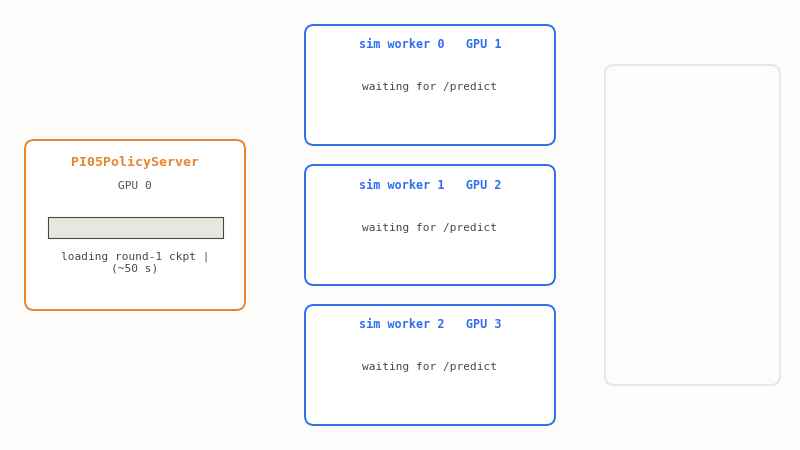

INFO 2026-08-24 20:32:53,704 serve 27637 -- Nothing to shut down. There's no Serve application running on this Ray cluster.
2026-08-24 20:32:54,215  INFO      released phase state on 1 GPU node(s)
2026-08-24 20:32:54,223  INFO      host headroom OK (at least one node): lowest is ip-10-0-35-1 with 155727 MiB available (need 68000)


(raylet) WARNING: 6 PYTHON worker processes have been started on node: e2540282a979ee7d9d27f7d0fd5d58171e0d7bc2e61c9029693fe41d with address: 100.103.200.12. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).


(TrainController pid=28142) Started training worker group of size 4: 
(TrainController pid=28142) - (ip=100.123.14.99, pid=29856) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=28142) - (ip=100.123.14.99, pid=29855) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=28142) - (ip=100.123.14.99, pid=29857) world_rank=2, local_rank=2, node_rank=0
(TrainController pid=28142) - (ip=100.123.14.99, pid=29858) world_rank=3, local_rank=3, node_rank=0
(TrainController pid=28142) [State Transition] SCHEDULING -> RUNNING.
  0%|          | 0.00/97.8M [00:00<?, ?B/s]14.99) 
 23%|██▎       | 22.5M/97.8M [00:00<00:00, 235MB/s]0m 


(RayTrainWorker pid=29856, ip=100.123.14.99) Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/ray/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


 47%|████▋     | 46.0M/97.8M [00:00<00:00, 241MB/s]0m 
(TrainController pid=28443) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=28443) Attempting to start training worker group of size 4 with the following resources: [{'GPU': 1}] * 4
 71%|███████   | 69.2M/97.8M [00:00<00:00, 242MB/s]0m 
100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]0m 
 74%|███████▍  | 72.2M/97.8M [00:00<00:00, 191MB/s]0m 
100%|██████████| 97.8M/97.8M [00:00<00:00, 249MB/s]0m 
100%|██████████| 97.8M/97.8M [00:00<00:00, 251MB/s]0m 
 96%|█████████▌| 93.6M/97.8M [00:00<00:00, 203MB/s]0m 
100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]0m 
100%|██████████| 21.1M/21.1M [00:00<00:00, 235MB/s]0m 
(RayTrainWorker pid=29856, ip=100.123.14.99) Moving model to device: cuda:0
(RayTrainWorker pid=29856, ip=100.123.14.99) Wrapping provided model in DistributedDataParallel.
(RayTrainWorker pid=29856, ip=100.123.14.99) /tmp/ipykernel_27785/1259924594.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args

...

(ServeController pid=28558) INFO 2026-08-24 20:34:14,690 controller 28558 -- No longer draining proxy on node 'd4547f289e5f507f12b08727aaf8507f4cf4af26414e4217bf31ccc8'.
(ServeReplica:pi05-policy:PI05PolicyServer pid=31194, ip=100.123.14.99) Traceback (most recent call last): [repeated 3x across cluster]
(ServeReplica:pi05-policy:PI05PolicyServer pid=31194, ip=100.123.14.99)     await self._call_func_or_gen( [repeated 3x across cluster]
(ServeReplica:pi05-policy:PI05PolicyServer pid=31194, ip=100.123.14.99)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/serve/_private/replica.py", line 1648, in _call_func_or_gen [repeated 3x across cluster]
(ServeReplica:pi05-policy:PI05PolicyServer pid=31194, ip=100.123.14.99)                         ^^^^^^^^^^^^^^^^^^^^^^^^^ [repeated 3x across cluster]
(ServeReplica:pi05-policy:PI05PolicyServer pid=31194, ip=100.123.14.99) ERROR 2026-08-24 20:34:11,502 pi05-policy_PI05PolicyServer lb0ce034 -- Exception during graceful shutdown of repli

RuntimeError: Deploying application pi05-policy failed: Failed to update the deployments ['PI05PolicyServer'].

(RayTrainWorker pid=31580, ip=100.123.14.99) Setting up process group for: env:// [rank=0, world_size=4]
(TrainController pid=28443) Started training worker group of size 4: 
(TrainController pid=28443) - (ip=100.123.14.99, pid=31580) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=28443) - (ip=100.123.14.99, pid=31581) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=28443) - (ip=100.123.14.99, pid=31583) world_rank=2, local_rank=2, node_rank=0
(TrainController pid=28443) - (ip=100.123.14.99, pid=31582) world_rank=3, local_rank=3, node_rank=0
(TrainController pid=28443) [State Transition] SCHEDULING -> RUNNING.


(autoscaler +2m5s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.


(RayTrainWorker pid=31580, ip=100.123.14.99) The PI05 model is a direct port of the OpenPI implementation. 
(RayTrainWorker pid=31580, ip=100.123.14.99) This implementation follows the original OpenPI structure for compatibility. 
(RayTrainWorker pid=31580, ip=100.123.14.99) Original implementation: https://github.com/Physical-Intelligence/openpi
(TrainController pid=30138) libcusparseLt.so.0: cannot open shared object file: No such file or directory
(TrainController pid=30138) Traceback (most recent call last):
(TrainController pid=30138)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/serialization.py", line 595, in deserialize_objects
(TrainController pid=30138)     obj = self._deserialize_object(
(TrainController pid=30138)           ^^^^^^^^^^^^^^^^^^^^^^^^^
(TrainController pid=30138)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/serialization.py", line 432, in _deserialize_object
(TrainController pid=30138)     return self._deseriali

In [6]:
from tools.viz import show_gif
show_gif("assets/nb03_cell6.gif",
         caption="deploy (~85s) -> Isaac boot -> HTTP-stepped eval -> GPUs freed; then: the SAME script at N workers = thousands of episodes and a success curve per round")
         
r1_episodes = run_sim_eval(R1_CKPT, "round1")
print("\nRound 1 episodes:", len(r1_episodes))

## Cell 7: Watch the round-1 rollouts

**What you do:** display the saved GIFs inline.

**What to check:** the Franka arm moves (likely exploratory). Each GIF corresponds to one worker/episode.

**Why it matters:** visual confirmation the served policy actually drove the
simulator end to end.

In [ ]:
from IPython.display import Image, display, Markdown

for ep in r1_episodes:
    gif = ep.get("gif_path")
    if gif and os.path.exists(gif):
        display(Markdown(f"**Round 1 - worker {ep['worker_id']} - ep {ep['episode']}** "
                         f"reward={ep['total_reward']:.3f}"))
        display(Image(filename=gif))

## Cell 8: The closed loop (`build_mixed_dataset`)

**What you do:** define `build_mixed_dataset`: glob the round-1 trajectory
pickles, parse the reward from each filename, keep episodes with
`reward >= REWARD_THRESHOLD`, turn the kept frames into a Ray Data dataset with
`ray.data.from_items`, and `union()` them with the LIBERO stream.

**What to check:** the one line that closes the loop:
`mixed = libero_ds.union(sim_ds)`. No custom sampler, no DataLoader subclass.

**Why it matters:** data mixing is a one-liner and the training loop is unchanged.

In [ ]:
def build_mixed_dataset(libero_ds, round_name):
    """Load sim trajectories from round_name, filter by reward, union with LIBERO.

    Ray Data's union() interleaves both sources during iteration, with no custom
    sampler, no DataLoader subclass. The training loop is unchanged.
    """
    traj_dir  = CLUSTER_STORAGE_ROOT / "trajectories" / round_name
    pkl_files = sorted(glob.glob(str(traj_dir / "*.pkl")))

    if not pkl_files:
        print(f"No trajectory files in {traj_dir}, using LIBERO only")
        return libero_ds

    kept_frames = []
    for path in pkl_files:
        try:
            reward = float(Path(path).stem.split("_reward")[-1])
        except (IndexError, ValueError):
            reward = 0.0
        status = "KEEP" if reward >= REWARD_THRESHOLD else "DROP"
        print(f"  {status}  {Path(path).name}  (reward={reward:.3f})")
        if reward >= REWARD_THRESHOLD:
            with open(path, "rb") as f:
                episode_frames = pickle.load(f)
            # One pickle is one episode, frames in order. Sim workers record a
            # single executed action per frame, but the LIBERO side now carries
            # (ACTION_CHUNK_SIZE, action_dim) chunks -- union() would otherwise
            # see two different shapes for `action` and training would break on
            # whichever batch came from the other source.
            kept_frames.extend(
                util.chunk_episode_actions(episode_frames, ACTION_CHUNK_SIZE)
            )

    if not kept_frames:
        print(f"No episodes passed threshold {REWARD_THRESHOLD}, using LIBERO only")
        return libero_ds

    print(f"\nSim frames kept: {len(kept_frames)} "
          f"(from {sum(1 for p in pkl_files if float(Path(p).stem.split('_reward')[-1]) >= REWARD_THRESHOLD)} episodes)")

    sim_ds = (
        ray.data.from_items(kept_frames)
        .map_batches(
            transpose_images, batch_size=32,
            fn_args=(["observation.images.image", "observation.images.image2"],),
        )
    )

    mixed = libero_ds.union(sim_ds)   # <-- THE CLOSED LOOP, one line
    print(f"Mixed dataset: LIBERO ({TOTAL_FRAMES:,} frames) ∪ sim ({len(kept_frames)} frames)")
    return mixed

## Cell 9: Build the mixed dataset

**What you do:** filter round-1 trajectories and union the survivors into LIBERO.

**What to check:** `KEEP`/`DROP` decisions per trajectory and the final mixed
frame counts. At demo scale with a train/eval mismatch, few or no sim episodes
may clear the threshold. The function falls back to LIBERO-only, which is fine as
the orchestration mechanism is the lesson.

**Why it matters:** this is the data artifact the round-2 trainer consumes.

In [ ]:
mixed_ds = build_mixed_dataset(build_libero_dataset(), "round1")
print(mixed_ds)

## Cell 10: Round-2 retrain on the mixed data

**What you do:** call the **same** `run_training` from Cell 4 on `mixed_ds`.

**What to check:** identical `(RayTrainWorker ...)` `step=`/`loss=` logs as
notebook 02; a `checkpoint_round2/state.pkl` is written.

**Why it matters:** the entire difference between round 1 and round 2 is the
dataset argument. That is the closed loop.

> **Re-running note:** as in notebook 02, Ray Train resumes from a populated
> `storage_path`. Clear the `vla-finetune-round2` run directory to retrain from
> scratch.

In [ ]:
from tools.viz import show_gif
show_gif("assets/nb03_cell10.gif",
         caption="same run_training, new data: mixed LIBERO+sim shards -> DDP retrain -> checkpoint_round2; then: the flywheel over N rounds, kept rollouts compound")

r2_ckpt, r2_metrics = run_training(mixed_ds, "round2")
print("\nRound 2 checkpoint:", r2_ckpt)
print("Round 2 metrics:", r2_metrics)

## Cell 11: Deploy round 2 + sim eval

**What you do:** serve the round-2 checkpoint and run the same sim eval again.

**Why it matters:** head-to-head with round 1 under identical conditions.

In [ ]:
from tools.viz import show_gif
show_gif("assets/nb03_cell11.gif",
         caption="head-to-head: same seeds, same harness, one variable (the checkpoint) -> the reward delta is attributable; at N episodes the distributions separate")

r2_episodes = run_sim_eval(r2_ckpt, "round2")
print("\nRound 2 episodes:", len(r2_episodes))

## Cell 12: Watch the round-2 rollouts

In [ ]:
for ep in r2_episodes:
    gif = ep.get("gif_path")
    if gif and os.path.exists(gif):
        display(Markdown(f"**Round 2 - worker {ep['worker_id']} - ep {ep['episode']}** "
                         f"reward={ep['total_reward']:.3f}"))
        display(Image(filename=gif))

## Cell 13: Results: round 1 vs round 2

**What you do:** tabulate sim reward per episode across rounds.

**What to check:** at 50 train steps on a 3.4B model rewards won't move much. The **loop closing** (and the unchanged
trainer) is what this validates. For real movement, set `MAX_TRAIN_STEPS=None`.

**Why it matters:** this is the metric the full-scale flywheel optimizes. Here
we prove the plumbing end to end.

In [ ]:
print("=" * 56)
print("Sim reward: Round 1 (notebook-02 ckpt) vs Round 2 (mixed)")
print("=" * 56)
print(f"Round 2 training loss: {r2_metrics.get('loss', float('nan')):.4f}")
print()
print(f"{'episode':<12}{'R1 reward':>12}{'R2 reward':>12}{'delta':>10}")
print("-" * 46)

r1_by = {(e['worker_id'], e['episode']): e for e in r1_episodes}
r2_by = {(e['worker_id'], e['episode']): e for e in r2_episodes}
for key in sorted(set(r1_by) | set(r2_by)):
    a = r1_by.get(key, {}).get('total_reward', float('nan'))
    b = r2_by.get(key, {}).get('total_reward', float('nan'))
    print(f"{('w%d ep%d' % key):<12}{a:>12.3f}{b:>12.3f}{(b - a):>+10.3f}")

print("-" * 46)
r1m = np.mean([e['total_reward'] for e in r1_episodes]) if r1_episodes else float('nan')
r2m = np.mean([e['total_reward'] for e in r2_episodes]) if r2_episodes else float('nan')
print(f"{'mean':<12}{r1m:>12.3f}{r2m:>12.3f}{(r2m - r1m):>+10.3f}")
print("=" * 56)

## Conclusion

You served a fine-tuned PI0.5 policy with **Ray Serve**, fanned out parallel
**Isaac Lab** rollouts as `@ray.remote(num_gpus=1)` tasks that queried it over
HTTP, then **closed the loop:** filtering sim trajectories by reward and
`union()`-ing them into the LIBERO stream, and retrained with the **unchanged**
trainer from notebook 02.

**Ray primitives used:** `@serve.deployment`, `serve.run`, `@ray.remote(num_gpus=1)`,
`ray.data.from_items`, `ray.data.union`, plus the `TorchTrainer` from 02.

**Scaling levers:** `SIM_WORKERS` (more parallel simulators); Serve replicas /
autoscaling (more inference throughput); `MAX_TRAIN_STEPS=None` (real retrain);
wrap the round in a `for` loop for more flywheel iterations.

Next, **`04_world_model_pretraining.ipynb`** moves from *using* a simulator to
*learning* one: pre-training a V-JEPA world model at scale with the same Ray Data / Ray Train stack.